In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Ensure the notebook can find the /src directory
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [2]:
from src.vessel_data import VesselDataProcessor

Successfully loaded and cleaned 2880 telemetry rows.
             Sample time  AE_POWER(kW)  DG_1_POWER(GByte)  DG_2_POWER(GByte)  \
2875 2025-12-31 23:40:00     377.93892             1584.0              784.0   
2876 2025-12-31 23:45:00     380.87293             1584.0              784.0   
2877 2025-12-31 23:50:00     386.18563             1584.0              784.0   
2878 2025-12-31 23:55:00     385.93173             1584.0              784.0   
2879 2026-01-01 00:00:00     389.06704             1584.0              784.0   

      DG_3_POWER(GByte)  GE162(kW)  GE163(A)  GE164  GE262(kW)   GE263(A)  \
2875             1494.0        0.0       0.0    0.0  378.47263  575.62134   
2876             1494.0        0.0       0.0    0.0  382.22141  581.09136   
2877             1494.0        0.0       0.0    0.0  385.98485  589.18860   
2878             1494.0        0.0       0.0    0.0  386.04467  585.44749   
2879             1494.0        0.0       0.0    0.0  389.93814  590.59071   

   

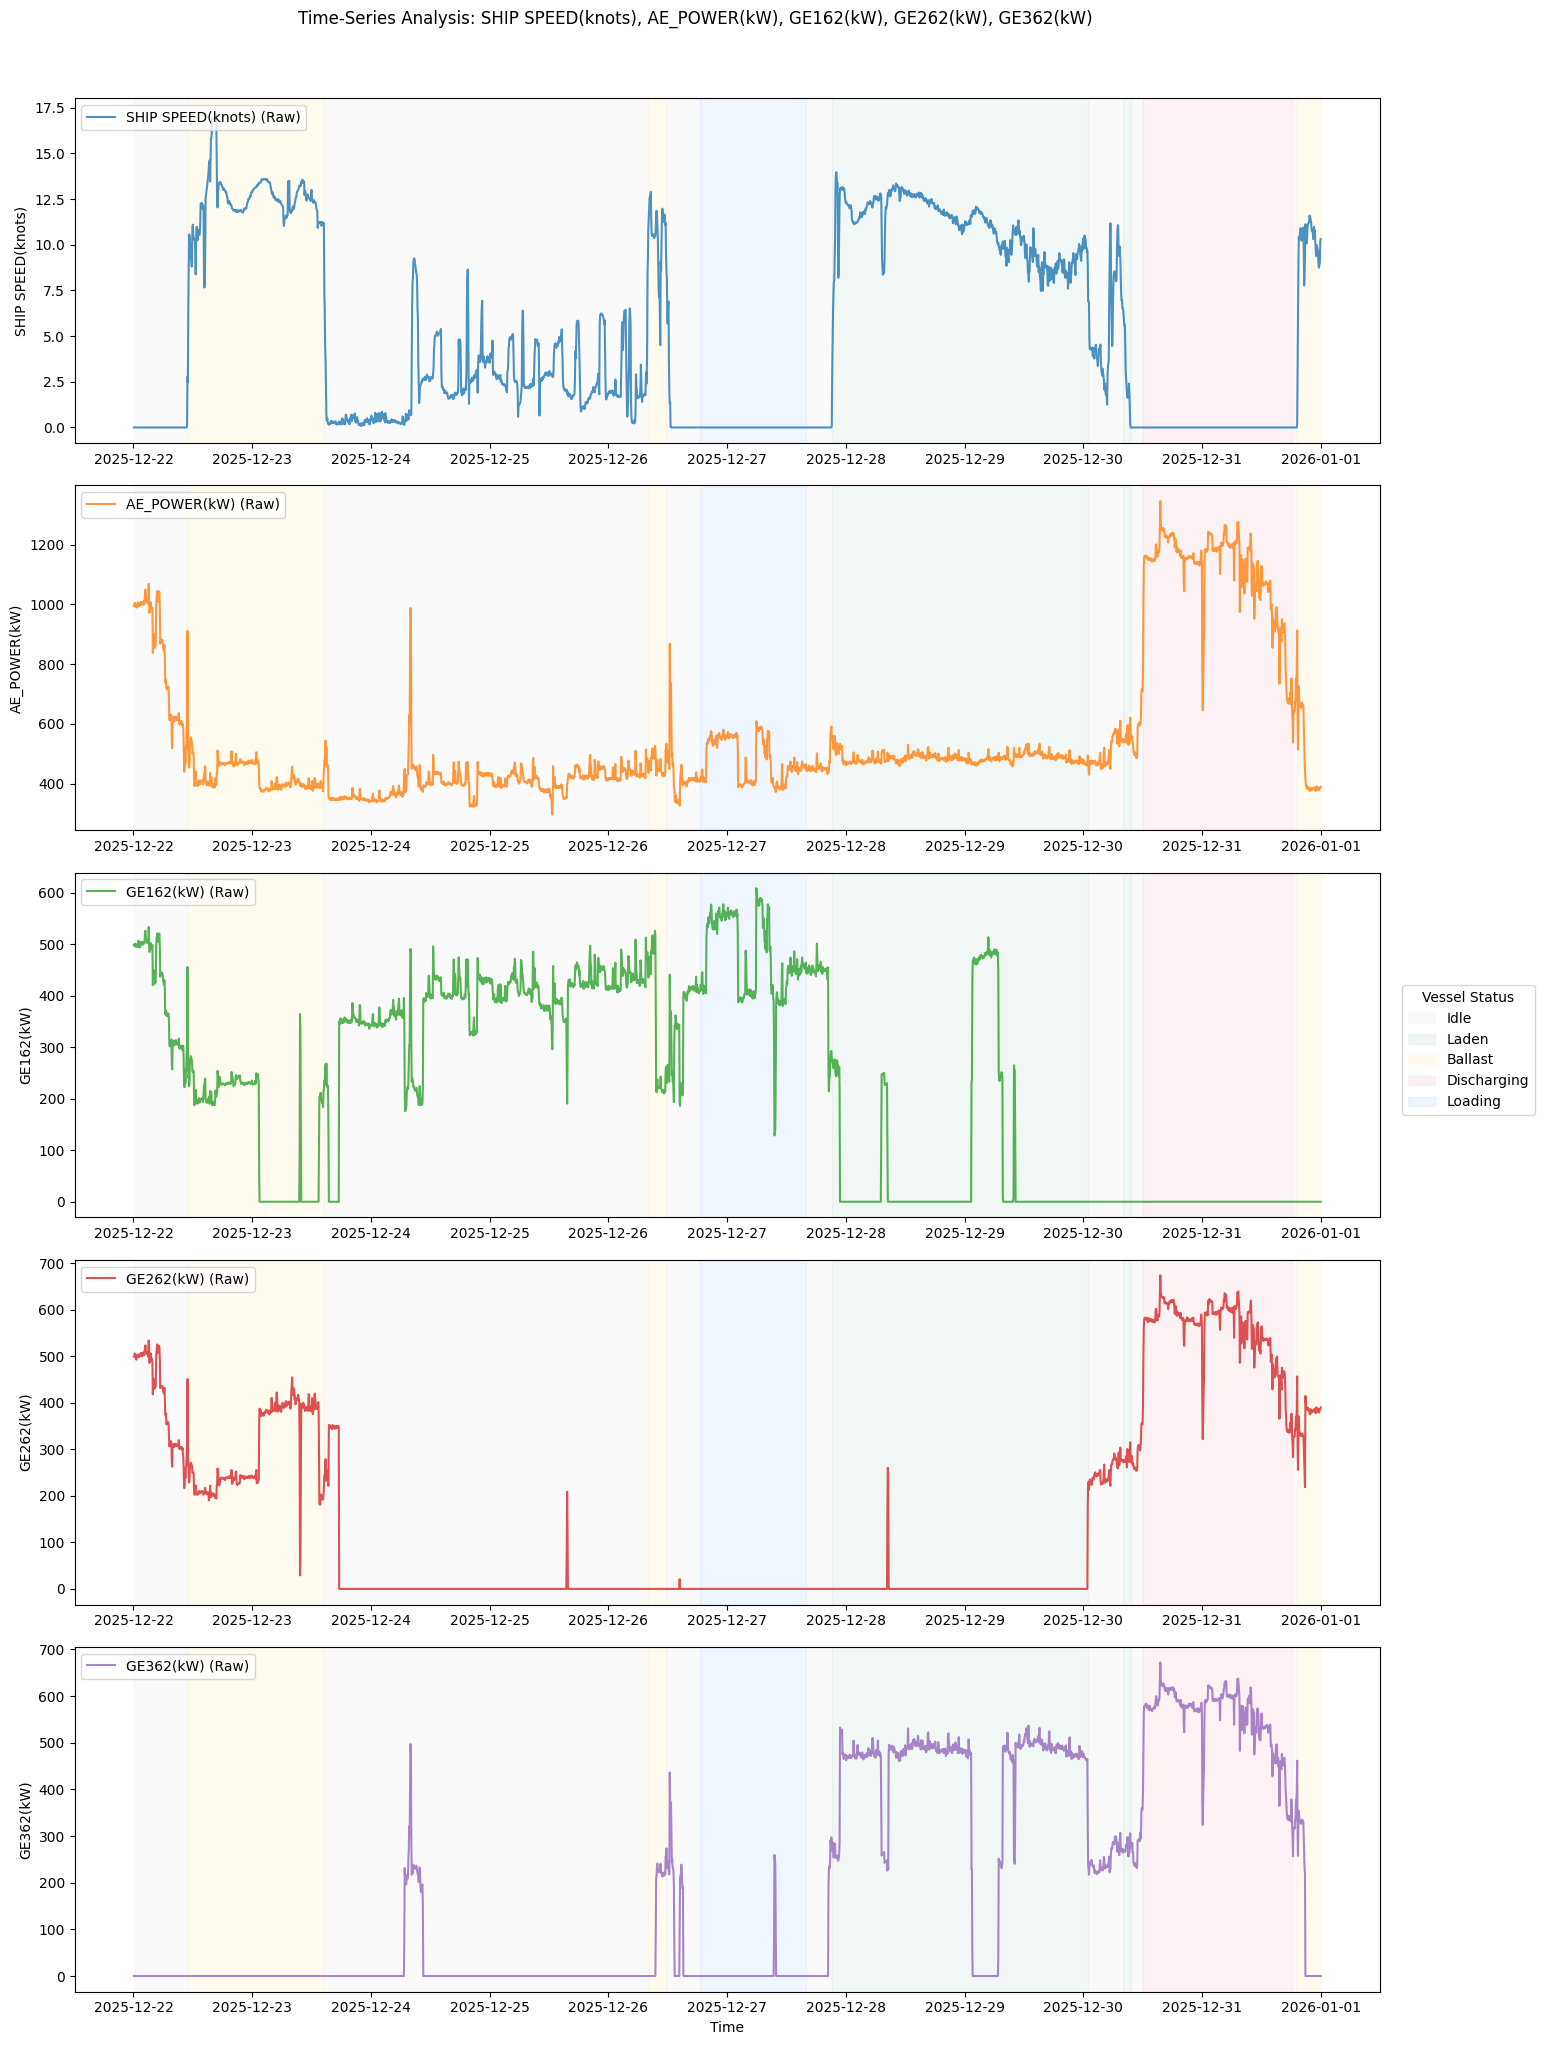

In [10]:
# Path to your raw telemetry
raw_data_file1 = root_path / "data" / "raw" / "Rotherhithe_voy_179.csv"

# Instantiate
processor1 = VesselDataProcessor(raw_data_file1)

# The new load_data now stops before the definitions footer
processor1.load_data(time_col="Sample time", date_format="%d/%m/%y %H:%M")

# Check if the last rows are actual data
print(processor1.df.tail()) 

# Extract metadata separately
metadata_df = processor1.extract_metadata()
print(metadata_df)

# Process coordinates
processor1.process_coordinates()

# Run sanity checks
processor1.sanity_check()

# Let's plot power and ship speed
cols_to_plot = ['SHIP SPEED(knots)', 'AE_POWER(kW)', 'GE162(kW)', 'GE262(kW)', 'GE362(kW)']

fig, axes = processor1.plot_series(
    columns=cols_to_plot, 
    subplots=True,
    show_status=True,
    secondary_y='SHIP SPEED(knots)',
)

In [4]:
# Plot vessel trajectory on a map
vessel_map1 = processor1.plot_trajectory_folium()
vessel_map1

Successfully loaded 3168 telemetry rows.
             Sample time  AE_POWER(kW)  DG_1_POWER(GByte)  DG_2_POWER(GByte)  \
3163 2026-02-02 23:40:00     425.34527              335.0              374.0   
3164 2026-02-02 23:45:00     438.56612              335.0              374.0   
3165 2026-02-02 23:50:00     442.39417              335.0              374.0   
3166 2026-02-02 23:55:00     423.22106              335.0              374.0   
3167 2026-02-03 00:00:00     417.96019              335.0              374.0   

      DG_3_POWER(GByte)  GE162(kW)  GE163(A)  GE164  GE262(kW)  GE263(A)  ...  \
3163              151.0        0.0       0.0    0.0        0.0       0.0  ...   
3164              151.0        0.0       0.0    0.0        0.0       0.0  ...   
3165              151.0        0.0       0.0    0.0        0.0       0.0  ...   
3166              151.0        0.0       0.0    0.0        0.0       0.0  ...   
3167              151.0        0.0       0.0    0.0        0.0       0.0 

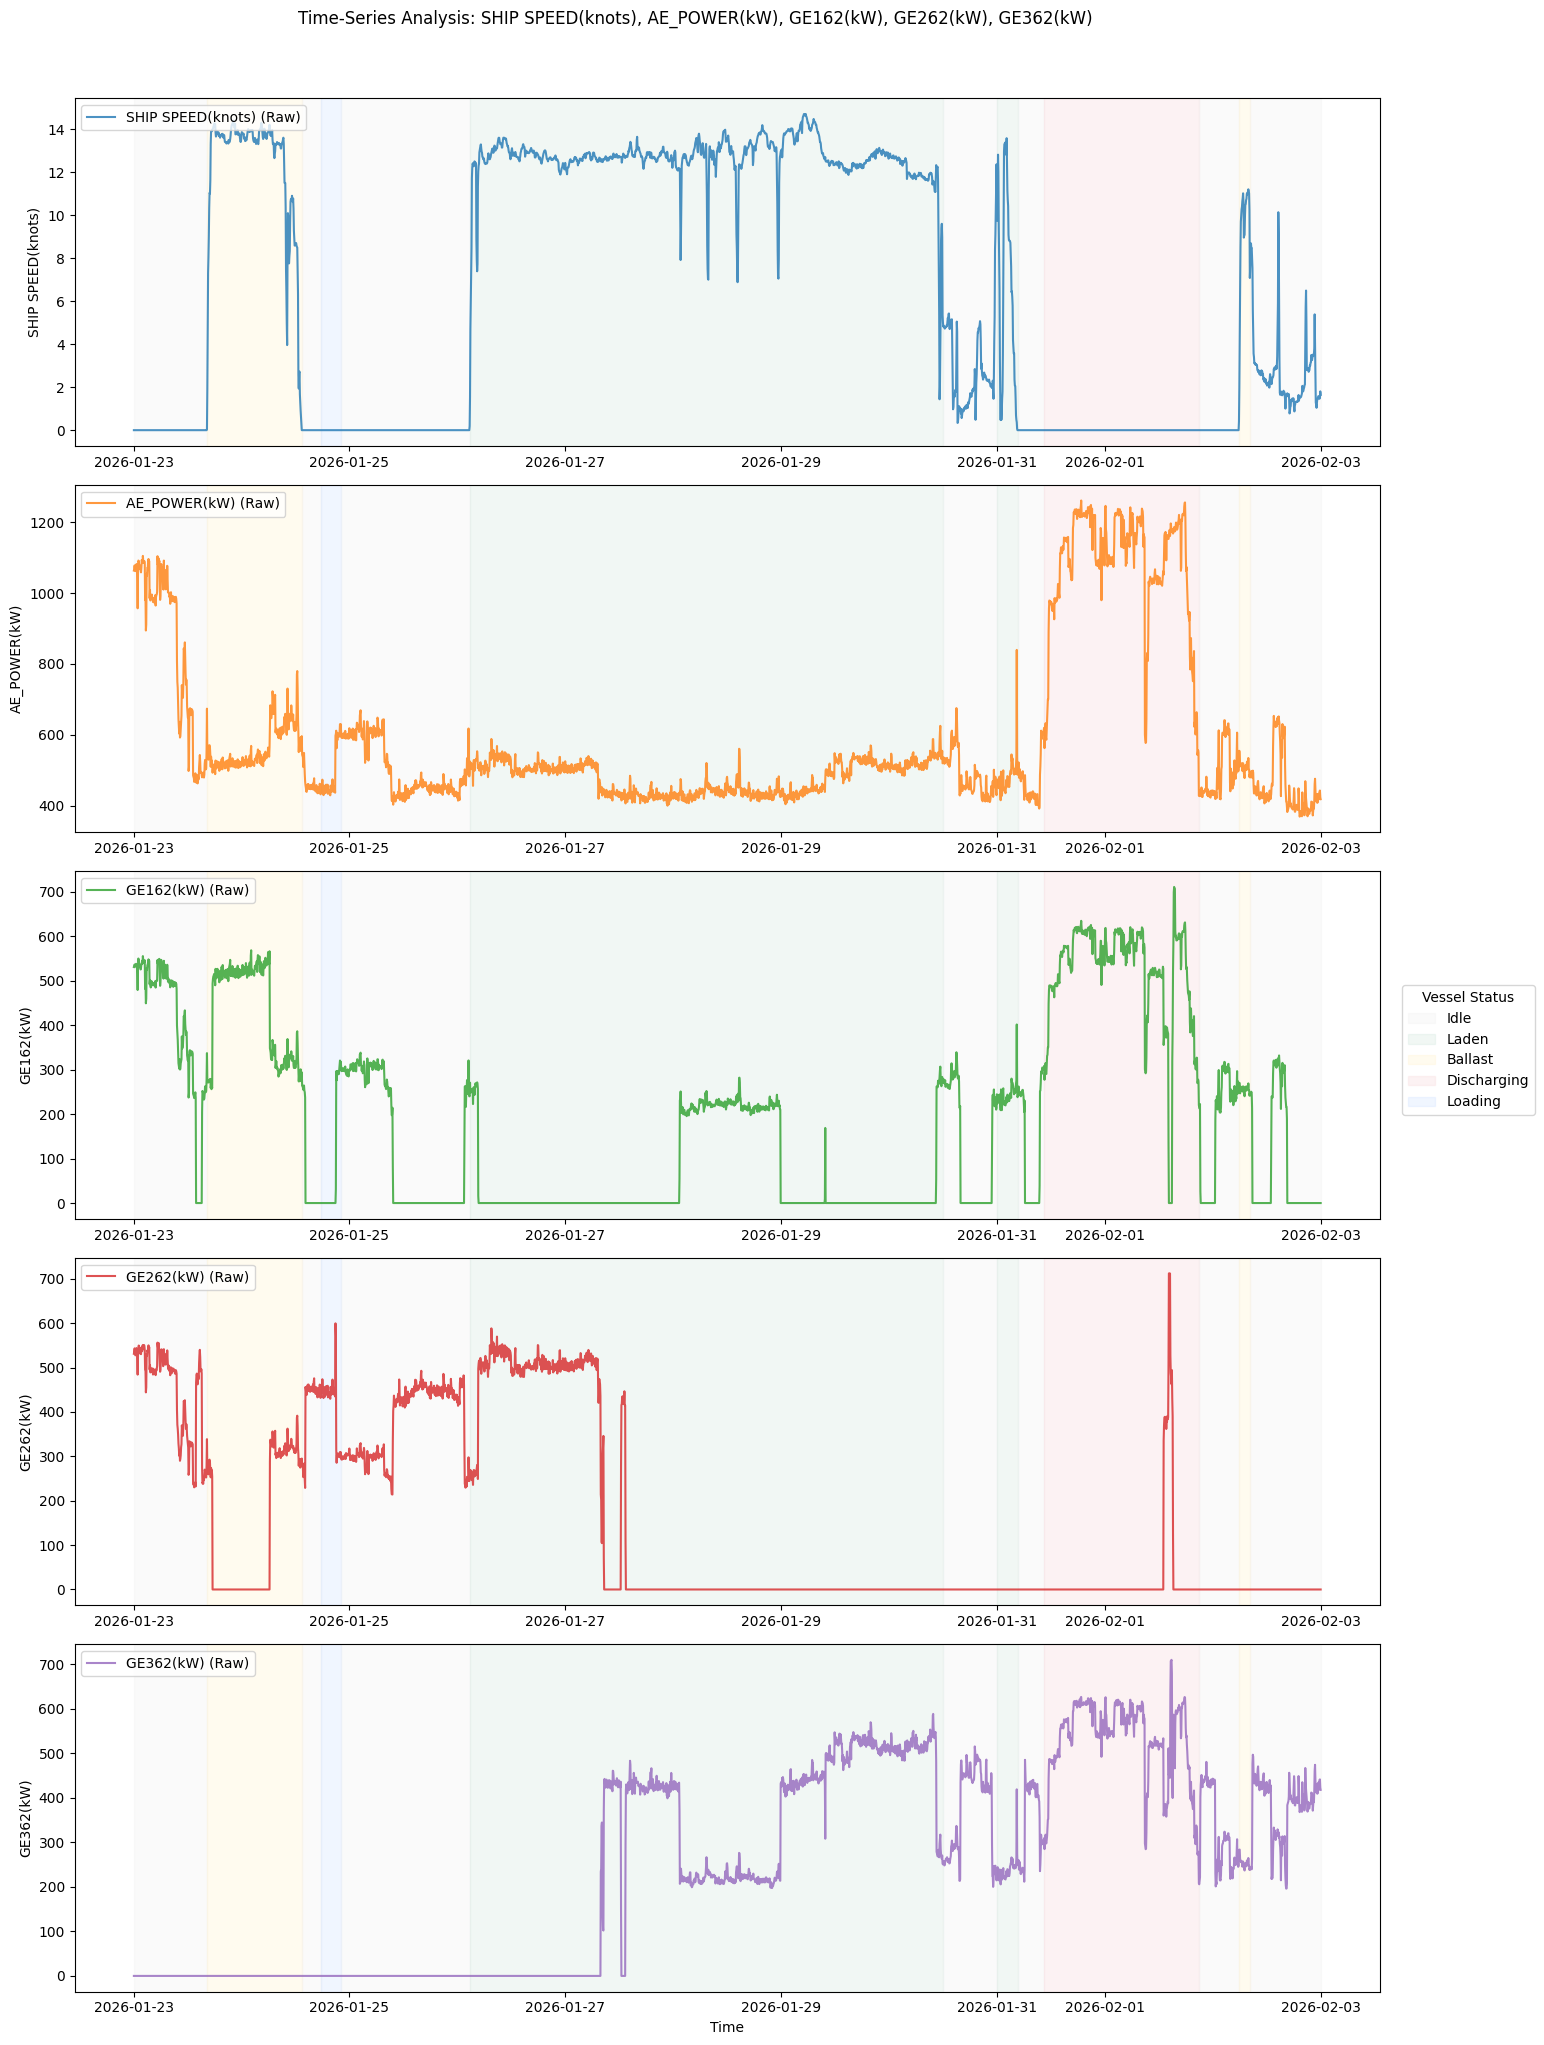

In [8]:
# Path to your raw telemetry
raw_data_file2 = root_path / "data" / "raw" / "Wembley_voy_236.csv"

# Instantiate
processor2 = VesselDataProcessor(raw_data_file2)

# Load data
processor2.load_data(time_col="Sample time", date_format="%d/%m/%y %H:%M")

# Check tail
print(processor2.df.tail()) 

# Extract metadata
metadata_df = processor2.extract_metadata()
print(metadata_df)

# Process coordinates
processor2.process_coordinates()

# Run sanity checks
processor2.sanity_check()

# Plot power and ship speed (subplots=False ici selon ton JSON)
cols_to_plot = ['SHIP SPEED(knots)', 'AE_POWER(kW)', 'GE162(kW)', 'GE262(kW)', 'GE362(kW)']

fig, axes = processor2.plot_series(
    columns=cols_to_plot, 
    subplots=True,
    show_status=True,
)

In [7]:
# Plot vessel trajectory on a map
vessel_map2 = processor2.plot_trajectory_folium()
vessel_map2